# Notebook 0 — Data at a Glance

Structural orientation for the NJ ACS 5-year (2020–2024) pull before any uncertainty math. We load all three geography levels, inspect shapes and missingness, and render quick boundary maps.

**ACS (American Community Survey):** ongoing Census Bureau survey; every estimate ships with a **MOE (margin of error)** at 90% confidence.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'JL_Analysis':
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'analysis' / 'JL_Analysis'
sys.path.insert(0, str(NOTEBOOK_DIR))

from helpers import (
    GEO_LABELS,
    GEO_LEVELS,
    VARIABLES,
    annotation_mask,
    estimate_moe_cols,
    load_acs,
    load_geo,
)

plt.rcParams['figure.dpi'] = 110

In [2]:
acs = {level: load_acs(level) for level in GEO_LEVELS}
geo = {level: load_geo(level) for level in GEO_LEVELS}

for level in GEO_LEVELS:
    df = acs[level]
    print(f"\n{'=' * 60}")
    print(f"{GEO_LABELS[level]} — {level}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print('\nColumns:')
    print(df.columns.tolist())
    print('\nDtypes:')
    print(df.dtypes)
    display(df.head(3))


County — county
Shape: 21 rows x 21 columns

Columns:
['STATE', 'COUNTY', 'NAME', 'B01003_001E', 'B01003_001M', 'B19013_001E', 'B19013_001M', 'B17001_002E', 'B17001_002M', 'B01001B_014E', 'B01001B_014M', 'B01001B_015E', 'B01001B_015M', 'B01001B_016E', 'B01001B_016M', 'B01001B_029E', 'B01001B_029M', 'B01001B_030E', 'B01001B_030M', 'B01001B_031E', 'B01001B_031M']

Dtypes:
STATE            object
COUNTY           object
NAME             object
B01003_001E       int64
B01003_001M     float64
B19013_001E       int64
B19013_001M       int64
B17001_002E       int64
B17001_002M       int64
B01001B_014E      int64
B01001B_014M      int64
B01001B_015E      int64
B01001B_015M      int64
B01001B_016E      int64
B01001B_016M      int64
B01001B_029E      int64
B01001B_029M      int64
B01001B_030E      int64
B01001B_030M      int64
B01001B_031E      int64
B01001B_031M      int64
dtype: object


,STATE,COUNTY,NAME,B01003_001E,B01003_001M,B19013_001E,B19013_001M,B17001_002E,B17001_002M,B01001B_014E,...,B01001B_015E,B01001B_015M,B01001B_016E,B01001B_016M,B01001B_029E,B01001B_029M,B01001B_030E,B01001B_030M,B01001B_031E,B01001B_031M
0,34,001,"Atlantic County, New Jersey",276270,NaN,78050,1834,35618,2930,1433,...,654,113,243,111,1784,214,1120,152,325,120
1,34,003,"Bergen County, New Jersey",962316,NaN,124884,1735,64606,3161,2120,...,783,146,384,122,2759,120,1299,243,598,160
2,34,005,"Burlington County, New Jersey",467805,NaN,108111,1600,30427,2322,2878,...,1353,175,448,158,3782,201,1961,193,910,192



Census tract — tract
Shape: 2,181 rows x 22 columns

Columns:
['STATE', 'COUNTY', 'TRACT', 'NAME', 'B01003_001E', 'B01003_001M', 'B19013_001E', 'B19013_001M', 'B17001_002E', 'B17001_002M', 'B01001B_014E', 'B01001B_014M', 'B01001B_015E', 'B01001B_015M', 'B01001B_016E', 'B01001B_016M', 'B01001B_029E', 'B01001B_029M', 'B01001B_030E', 'B01001B_030M', 'B01001B_031E', 'B01001B_031M']

Dtypes:
STATE            object
COUNTY           object
TRACT            object
NAME             object
B01003_001E       int64
B01003_001M       int64
B19013_001E     float64
B19013_001M     float64
B17001_002E       int64
B17001_002M       int64
B01001B_014E      int64
B01001B_014M      int64
B01001B_015E      int64
B01001B_015M      int64
B01001B_016E      int64
B01001B_016M      int64
B01001B_029E      int64
B01001B_029M      int64
B01001B_030E      int64
B01001B_030M      int64
B01001B_031E      int64
B01001B_031M      int64
dtype: object


,STATE,COUNTY,TRACT,NAME,B01003_001E,B01003_001M,B19013_001E,B19013_001M,B17001_002E,B17001_002M,...,B01001B_015E,B01001B_015M,B01001B_016E,B01001B_016M,B01001B_029E,B01001B_029M,B01001B_030E,B01001B_030M,B01001B_031E,B01001B_031M
0,34,001,000100,Census Tract 1; Atlantic County; New Jersey,2380,475,56222.0,13213.0,478,297,...,0,14,0,14,0,14,0,14,0,14
1,34,001,000200,Census Tract 2; Atlantic County; New Jersey,3009,549,42346.0,28560.0,624,357,...,0,14,0,14,0,14,0,14,0,14
2,34,001,000300,Census Tract 3; Atlantic County; New Jersey,4064,607,52763.0,18124.0,1149,509,...,0,14,0,14,0,14,0,14,0,14



Block group — block_group
Shape: 6,599 rows x 23 columns

Columns:
['STATE', 'COUNTY', 'TRACT', 'BLOCK_GROUP', 'NAME', 'B01003_001E', 'B01003_001M', 'B19013_001E', 'B19013_001M', 'B17001_002E', 'B17001_002M', 'B01001B_014E', 'B01001B_014M', 'B01001B_015E', 'B01001B_015M', 'B01001B_016E', 'B01001B_016M', 'B01001B_029E', 'B01001B_029M', 'B01001B_030E', 'B01001B_030M', 'B01001B_031E', 'B01001B_031M']

Dtypes:
STATE            object
COUNTY           object
TRACT            object
BLOCK_GROUP      object
NAME             object
B01003_001E       int64
B01003_001M       int64
B19013_001E     float64
B19013_001M     float64
B17001_002E     float64
B17001_002M     float64
B01001B_014E    float64
B01001B_014M    float64
B01001B_015E    float64
B01001B_015M    float64
B01001B_016E    float64
B01001B_016M    float64
B01001B_029E    float64
B01001B_029M    float64
B01001B_030E    float64
B01001B_030M    float64
B01001B_031E    float64
B01001B_031M    float64
dtype: object


,STATE,COUNTY,TRACT,BLOCK_GROUP,NAME,B01003_001E,B01003_001M,B19013_001E,B19013_001M,B17001_002E,...,B01001B_015E,B01001B_015M,B01001B_016E,B01001B_016M,B01001B_029E,B01001B_029M,B01001B_030E,B01001B_030M,B01001B_031E,B01001B_031M
0,34,001,000100,1,Block Group 1; Census Tract 1; Atlantic County...,1064,398,48833.0,19726.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,34,001,000100,2,Block Group 2; Census Tract 1; Atlantic County...,1316,368,58021.0,30232.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,34,001,000200,1,Block Group 1; Census Tract 2; Atlantic County...,1980,506,39208.0,12509.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Row counts by geography level

Smaller geographies nest inside larger ones, so row counts explode as we zoom in — the central empirical setup for this project.

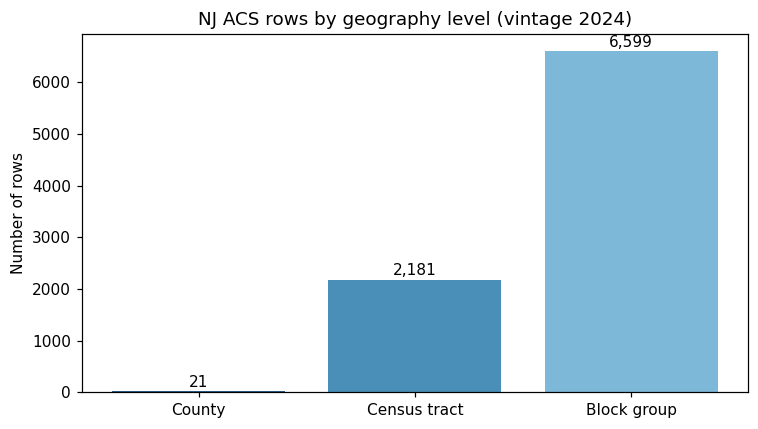

In [3]:
counts = pd.DataFrame({
    'Geography level': [GEO_LABELS[l] for l in GEO_LEVELS],
    'Rows': [len(acs[l]) for l in GEO_LEVELS],
})
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts['Geography level'], counts['Rows'], color=['#2c5f8a', '#4a8fb8', '#7eb8d8'])
ax.set_title('NJ ACS rows by geography level (vintage 2024)')
ax.set_ylabel('Number of rows')
for bar, val in zip(bars, counts['Rows']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 80, f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Missing values and annotation codes

**Annotation codes** are giant negative sentinel values the Census API returns instead of real numbers (e.g. `-555555555` = controlled estimate, `-666666666` = insufficient sample). Our client library converts them to blanks, so this chart shows combined null rates. See `docs/glossary.md`.

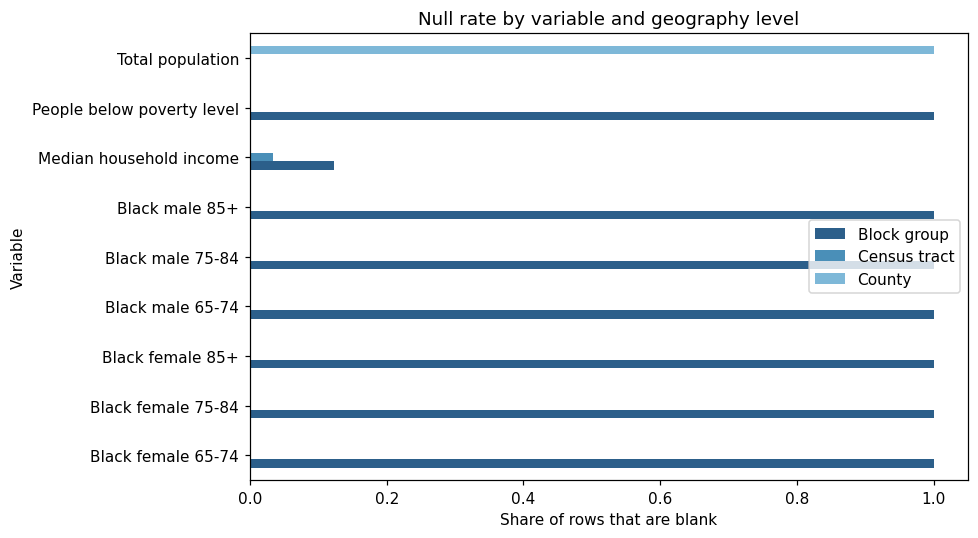

Block-group poverty and subgroup variables are 100% blank — expected; those tables are not published below tract level.


In [4]:
null_rows = []
for level in GEO_LEVELS:
    df = acs[level]
    for var_code in VARIABLES:
        est_col, moe_col = estimate_moe_cols(var_code)
        for col, kind in [(est_col, 'estimate'), (moe_col, 'MOE')]:
            if col not in df.columns:
                continue
            s = pd.to_numeric(df[col], errors='coerce')
            null_rows.append({
                'Geography level': GEO_LABELS[level],
                'Variable': VARIABLES[var_code],
                'Column type': kind,
                'Null rate': s.isna().mean(),
                'Annotation rate': annotation_mask(s).mean(),
            })

null_df = pd.DataFrame(null_rows)
pivot = null_df.pivot_table(
    index='Variable', columns='Geography level', values='Null rate', aggfunc='max'
)
fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind='barh', ax=ax, color=['#2c5f8a', '#4a8fb8', '#7eb8d8'])
ax.set_title('Null rate by variable and geography level')
ax.set_xlabel('Share of rows that are blank')
ax.legend(title='')
plt.tight_layout()
plt.show()

print('Block-group poverty and subgroup variables are 100% blank — expected; '
      'those tables are not published below tract level.')

## Quick boundary maps — does this look like New Jersey?

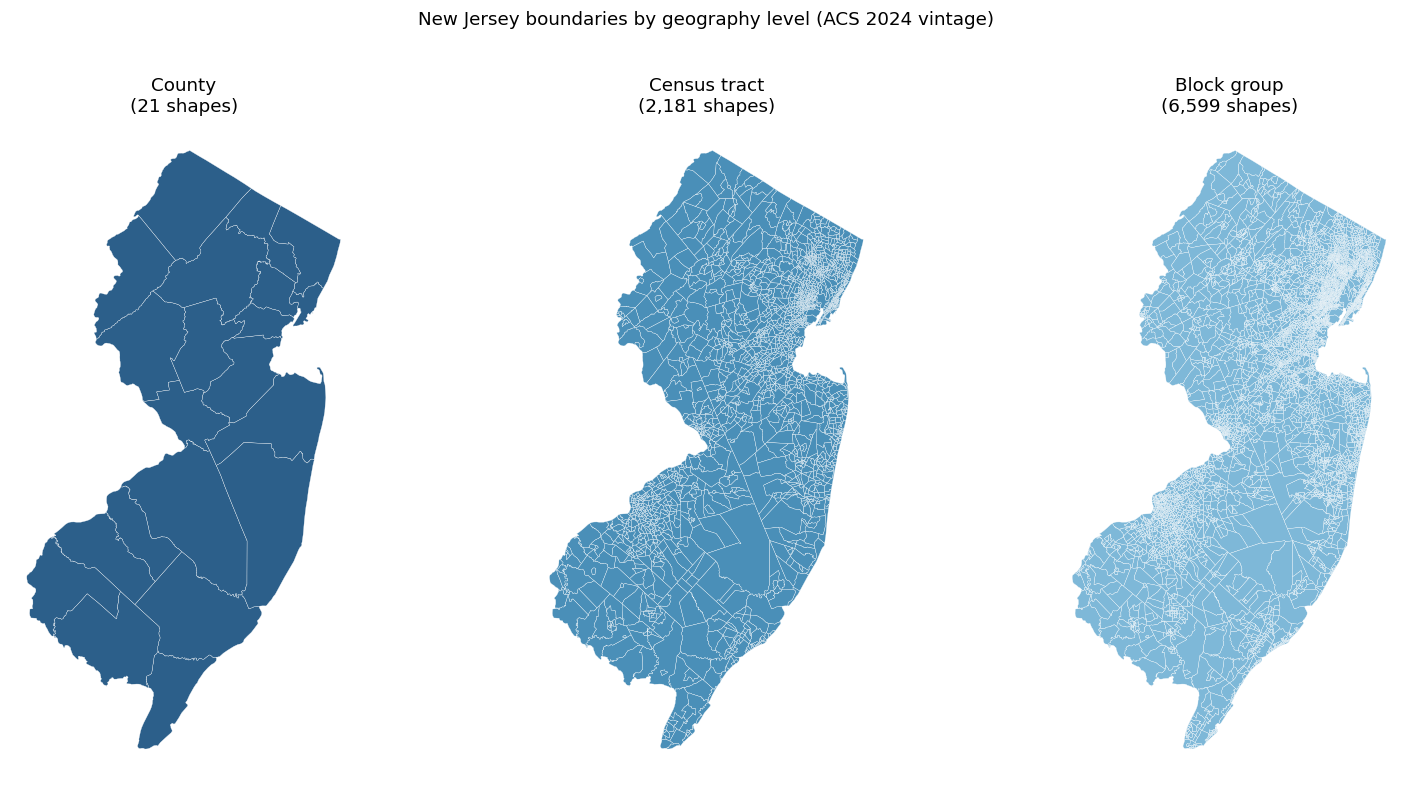

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
colors = ['#2c5f8a', '#4a8fb8', '#7eb8d8']
for ax, level, color in zip(axes, GEO_LEVELS, colors):
    gdf = geo[level]
    gdf.plot(ax=ax, color=color, edgecolor='white', linewidth=0.2)
    ax.set_title(f"{GEO_LABELS[level]}\n({len(gdf):,} shapes)")
    ax.set_axis_off()
fig.suptitle('New Jersey boundaries by geography level (ACS 2024 vintage)', y=1.02)
plt.tight_layout()
plt.show()